# Notebook 5: Robustness and Adversarial Evaluation

This notebook implements robustness techniques and adversarial evaluation for the HumanMAC motion prediction model, addressing Section 8.2 (Robustness and Security) of the project report.

**Robustness techniques:**

1. **Jittering augmentation**: Small Gaussian noise added to observed frames at test time; predictions from multiple jittered copies are averaged to smooth sensitivity to exact input values.
2. **Temperature scaling**: Post-hoc calibration of prediction variance by fitting a scalar temperature parameter on a held-out validation set. This rescales the diffusion sampling noise to produce better-calibrated uncertainty estimates.

**Adversarial evaluation:**

- **FGSM (Fast Gradient Sign Method)**: Single-step white-box attack that perturbs the DCT conditioning signal (`traj_dct_mod`) to maximise the diffusion model's noise prediction error.
- **PGD (Projected Gradient Descent)**: Multi-step iterative variant with random start, providing a stronger attack bound.

**Visualisations:** Robustness curves across attack budgets, calibration reliability diagrams, prediction variance histograms, and latency/memory benchmarking (also closing the MS2 gap for efficiency metrics).

## Section 1: Imports and Setup

Same imports as notebook 4. We additionally import `torch.nn.functional` for gradient-based adversarial attacks and `scipy.optimize` for temperature scaling calibration.

In [1]:
import sys, os, copy, time, json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace
from tqdm import tqdm
from scipy.optimize import minimize_scalar

REPO_ROOT = os.path.abspath('../HumanMAC/')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from config import Config, update_config
from utils import create_logger, seed_set, padding_traj, post_process
from utils.script import (create_model_and_diffusion, dataset_split,
                           get_multimodal_gt_full, sample_preprocessing)

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')


<IPython.core.display.Javascript object>

PyTorch version : 1.7.1+cu110
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4090


## Section 2: Configuration and Checkpoint Loading

Reuse config and EMA checkpoint from notebook 4.

In [2]:
seed_set(0)

# Change to repo root so Config can find ./cfg/h36m.yml and checkpoints resolve correctly
os.chdir(REPO_ROOT)

args = {
    'cfg': 'h36m', 'mode': 'test', 'iter': 0, 'seed': 0,
    'device': torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'),
    'multimodal_threshold': 0.5, 'multimodal_th_high': 0.1,
    'milestone': [75, 150, 225, 275, 350, 450], 'gamma': 0.9,
    'save_model_interval': 10, 'save_gif_interval': 10, 'save_metrics_interval': 100,
    'ckpt': './checkpoints/h36m_ckpt.pt',
    'ema': True, 'vis_switch_num': 10, 'vis_col': 5, 'vis_row': 3,
}

cfg = Config('h36m', test=False)
cfg = update_config(cfg, args)

print(f'Device          : {cfg.device}')
print(f't_his / t_pred  : {cfg.t_his} / {cfg.t_pred}')
print(f'n_pre (DCT)     : {cfg.n_pre}')
print(f'Joint count     : {cfg.joint_num}')

Device          : cuda
t_his / t_pred  : 25 / 100
n_pre (DCT)     : 20
Joint count     : 16


In [4]:
# Build model and diffusion, load trained EMA checkpoint
model, diffusion = create_model_and_diffusion(cfg)

CKPT_PATH = os.path.join(cfg.model_path, 'ckpt_ema_990.pt')
state_dict = torch.load(CKPT_PATH, map_location=cfg.device)
model.load_state_dict(state_dict)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f'Loaded checkpoint: {CKPT_PATH}')
print(f'Total parameters : {total_params/1e6:.2f}M')

Loaded checkpoint: results/test_12/models/ckpt_ema_990.pt
Total parameters : 28.40M


## Section 3: Dataset and Multimodal Ground Truth

Load H36M test split and build multimodal GT dictionary (same as notebook 4).

In [5]:
dataset, dataset_multi_test = dataset_split(cfg)
args_ns = SimpleNamespace(**args)

import logging
logger = logging.getLogger('robustness')
logger.setLevel(logging.INFO)
if not logger.handlers:
    logger.addHandler(logging.StreamHandler())

multimodal_dict = get_multimodal_gt_full(logger, dataset_multi_test, args_ns, cfg)

data_group  = multimodal_dict['data_group']
gt_group    = multimodal_dict['gt_group']
traj_gt_arr = multimodal_dict['traj_gt_arr']
num_samples = multimodal_dict['num_samples']

print(f'Test sequences  : {num_samples}')
print(f'data_group shape: {data_group.shape}')
print(f'gt_group shape  : {gt_group.shape}')

preparing full evaluation dataset...
#1 future: 73/5168
#<10 future: 1011/5168
done...


Test sequences  : 5168
data_group shape: (5168, 125, 17, 3)
gt_group shape  : (5168, 100, 48)


In [6]:
# ── Cache & adversarial-subset configuration ────────────────────────────────
# All expensive results are saved here; on rerun the cell loads instead of recomputing.
CACHE_DIR = './results/robustness/cache/'
os.makedirs(CACHE_DIR, exist_ok=True)

# Adversarial attacks run on a subset to avoid OOM during gradient computation.
# Full data_group (5168 sequences) requires storing activations for backward pass,
# which exceeds VRAM budget. 500 sequences is representative for robustness curves.
N_ADV     = 500
adv_data_group = data_group[:N_ADV]   # (N_ADV, t_his+t_pred, 17, 3)
adv_gt_group   = gt_group[:N_ADV]     # (N_ADV, t_pred, 48)

# Chunk size: sequences processed in one forward+backward inside attack functions.
# Keeps peak VRAM manageable during the gradient computation step.
ADV_CHUNK = 64

print(f'Full test set      : {data_group.shape[0]} sequences')
print(f'Adversarial subset : {N_ADV} sequences')
print(f'Attack chunk size  : {ADV_CHUNK} sequences per gradient step')
print(f'Cache directory    : {os.path.abspath(CACHE_DIR)}')


Full test set      : 5168 sequences
Adversarial subset : 500 sequences
Attack chunk size  : 64 sequences per gradient step
Cache directory    : /media/shimran/sh_imran/shah_imran/code/humanMAC_6450/inse_6450_project/HumanMAC/results/robustness/cache


## Section 4: Evaluation Helpers

`get_prediction` and `evaluate_ade_fde` reused from notebook 4. We add `get_prediction_from_traj_tensor` that accepts an already-preprocessed trajectory tensor (for adversarial attacks where we need gradient flow through the input).

In [7]:
def get_prediction(data, model_select, cfg, diffusion):
    """Run DDIM sampling on raw trajectory array.
    
    Args:
        data: (N, t_his+t_pred, joints, 3) raw trajectory
    Returns:
        traj_est: (1, N, t_his+t_pred, 48) predicted trajectory
    """
    traj_np = data[..., 1:, :].transpose([0, 2, 3, 1])
    traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
    traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)

    mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')
    sampled = diffusion.sample_ddim(model_select, traj_dct, traj_dct_cond, mode_dict)

    traj_est = torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], sampled)
    traj_est = traj_est.cpu().numpy()
    return traj_est[None, ...]

In [8]:
def evaluate_ade_fde(data_group, gt_group, traj_gt_arr, num_samples,
                     model_select, cfg, diffusion, K=50):
    """Compute ADE, FDE, MMADE, MMFDE over K prediction samples.
    
    Returns:
        results dict, per_seq_ade array, per_seq_fde array
    """
    pred_all = []
    for i in tqdm(range(K), desc='Sampling'):
        pred_i = get_prediction(data_group, model_select, cfg, diffusion)
        pred_all.append(pred_i)

    pred_all = np.concatenate(pred_all, axis=0)          # (K, N, t_his+t_pred, 48)
    pred_all = pred_all[:, :, cfg.t_his:, :]              # (K, N, t_pred, 48)

    pred_t = torch.from_numpy(pred_all).cuda()
    gt_t   = torch.from_numpy(gt_group).cuda() if not torch.is_tensor(gt_group) else gt_group.cuda()

    ade_list, fde_list, mmade_list, mmfde_list = [], [], [], []
    per_seq_ade = np.zeros(num_samples)
    per_seq_fde = np.zeros(num_samples)

    for j in range(num_samples):
        gt_multi_j = torch.from_numpy(traj_gt_arr[j]).cuda()
        gt_all_j = torch.cat([gt_multi_j, gt_t[j:j+1]], dim=0)[None, ...]
        pred_j   = pred_t[:, j:j+1, :, :]

        diff = pred_j - gt_all_j
        dist = torch.linalg.norm(diff, dim=3)

        ade_k = dist[:, -1].mean(dim=1)
        fde_k = dist[:, -1, -1]
        ade_best = ade_k.min().item()
        fde_best = fde_k.min().item()

        mmade_k = dist[:, :-1].mean(dim=2).min(dim=0)[0].mean().item()
        mmfde_k = dist[:, :-1, -1].min(dim=0)[0].mean().item()

        ade_list.append(ade_best)
        fde_list.append(fde_best)
        mmade_list.append(mmade_k)
        mmfde_list.append(mmfde_k)
        per_seq_ade[j] = ade_best
        per_seq_fde[j] = fde_best

    results = {
        'ADE': np.mean(ade_list), 'FDE': np.mean(fde_list),
        'MMADE': np.mean(mmade_list), 'MMFDE': np.mean(mmfde_list),
    }
    return results, per_seq_ade, per_seq_fde

## Section 5: Clean Baseline

Run the standard evaluation to establish reference ADE/FDE. All subsequent results are compared against this baseline.

In [9]:
_baseline_cache  = os.path.join(CACHE_DIR, 'baseline_results.json')
_baseline_per_cache = os.path.join(CACHE_DIR, 'baseline_per.npz')

if os.path.exists(_baseline_cache) and os.path.exists(_baseline_per_cache):
    with open(_baseline_cache) as f:
        baseline_results = json.load(f)
    _d = np.load(_baseline_per_cache)
    baseline_per_ade = _d['ade'].tolist()
    baseline_per_fde = _d['fde'].tolist()
    print('Loaded baseline results from cache.')
else:
    baseline_results, baseline_per_ade, baseline_per_fde = evaluate_ade_fde(
        data_group, gt_group, traj_gt_arr, num_samples, model, cfg, diffusion, K=50
    )
    with open(_baseline_cache, 'w') as f:
        json.dump(baseline_results, f, indent=2)
    np.savez(_baseline_per_cache, ade=baseline_per_ade, fde=baseline_per_fde)

print('Clean Baseline Results:')
for k, v in baseline_results.items():
    print(f'  {k:6s}: {v:.4f}')


Loaded baseline results from cache.
Clean Baseline Results:
  ADE   : 0.3691
  FDE   : 0.4776
  MMADE : 0.5103
  MMFDE : 0.5435


## Section 6: Jittering Augmentation (Test-Time)

For each test sequence, we create `M` jittered copies by adding small Gaussian noise (sigma_jitter) to the observed frames, run prediction on each copy, and **average** the K×M predicted futures. This smooths out input sensitivity and should improve robustness to sensor noise without retraining.

- `M_jitter`: number of jittered copies (default 5)
- `sigma_jitter`: noise scale for jittering (0.02, a mild perturbation)

In [10]:
_jitter_preds_cache = os.path.join(CACHE_DIR, 'pred_jitter_future.npz')

if os.path.exists(_jitter_preds_cache):
    pred_jitter_future = np.load(_jitter_preds_cache)['arr']
    print(f'Loaded jittered predictions from cache: {pred_jitter_future.shape}')
else:
    M_JITTER = 5
    SIGMA_JITTER = 0.02
    K_PER_JITTER = 10  # K samples per jittered copy, total effective K = M*K_per = 50

    pred_jitter_all = []
    for m in tqdm(range(M_JITTER), desc='Jitter copies'):
        data_jittered = data_group.copy()
        noise = np.random.randn(*data_jittered[:, :cfg.t_his, 1:, :].shape) * SIGMA_JITTER
        data_jittered[:, :cfg.t_his, 1:, :] += noise

        for k in range(K_PER_JITTER):
            pred_i = get_prediction(data_jittered, model, cfg, diffusion)
            pred_jitter_all.append(pred_i)

    # pred_jitter_all: (M*K, N, t_his+t_pred, 48)
    pred_jitter_all = np.concatenate(pred_jitter_all, axis=0)
    pred_jitter_future = pred_jitter_all[:, :, cfg.t_his:, :]  # (50, N, t_pred, 48)
    np.savez_compressed(_jitter_preds_cache, arr=pred_jitter_future)

print(f'Jittered predictions shape: {pred_jitter_future.shape}')


Loaded jittered predictions from cache: (50, 5168, 100, 48)
Jittered predictions shape: (50, 5168, 100, 48)


In [11]:
_jitter_results_cache = os.path.join(CACHE_DIR, 'jitter_results.json')

if os.path.exists(_jitter_results_cache):
    with open(_jitter_results_cache) as f:
        jitter_results = json.load(f)
    print('Loaded jitter results from cache.')
else:
    # Evaluate jittered predictions using same metric loop
    pred_jt = torch.from_numpy(pred_jitter_future).cuda()
    gt_t    = torch.from_numpy(gt_group).cuda()

    jitter_ade_list, jitter_fde_list = [], []
    for j in range(num_samples):
        gt_j = gt_t[j:j+1]                       # (1, t_pred, 48)
        pred_j = pred_jt[:, j, :, :]              # (50, t_pred, 48)
        diff = pred_j - gt_j                      # (50, t_pred, 48)
        dist = torch.linalg.norm(diff, dim=2)     # (50, t_pred)
        ade_k = dist.mean(dim=1)                  # (50,)
        fde_k = dist[:, -1]                       # (50,)
        jitter_ade_list.append(ade_k.min().item())
        jitter_fde_list.append(fde_k.min().item())

    jitter_results = {'ADE': np.mean(jitter_ade_list), 'FDE': np.mean(jitter_fde_list)}
    with open(_jitter_results_cache, 'w') as f:
        json.dump(jitter_results, f, indent=2)

print(f'Jittering Augmentation Results:')
print(f'  ADE: {jitter_results["ADE"]:.4f}  (baseline: {baseline_results["ADE"]:.4f})')
print(f'  FDE: {jitter_results["FDE"]:.4f}  (baseline: {baseline_results["FDE"]:.4f})')


Loaded jitter results from cache.
Jittering Augmentation Results:
  ADE: 0.4825  (baseline: 0.3691)
  FDE: 0.5312  (baseline: 0.4776)


## Section 7: Temperature Scaling (Post-hoc Calibration)

Since the diffusion model generates stochastic predictions, we can treat the per-sample prediction variance as an uncertainty proxy. Temperature scaling fits a single scalar `T` that rescales the initial noise magnitude during DDIM sampling, so that the empirical coverage of prediction intervals better matches the nominal confidence level.

We use a small held-out calibration subset (first 20% of test sequences). For each candidate temperature `T`, we scale the initial noise by `T`, generate K samples, compute the empirical coverage of the 90% prediction interval, and select `T` that minimises `|coverage - 0.90|`.

In [12]:
def predict_with_temperature(data, model_sel, cfg, diffusion, T, K=20):
    """Generate K predictions with scaled initial noise (temperature T).
    
    Returns:
        preds: (K, N, t_pred, 48) future predictions
    """
    traj_np = data[..., 1:, :].transpose([0, 2, 3, 1])
    traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
    traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)
    mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')

    preds = []
    for _ in range(K):
        # Scale initial noise by temperature T
        n = mode_dict['sample_num']
        scaled_noise = T * torch.randn(
            (n, diffusion.motion_size[0], diffusion.motion_size[1])
        ).to(cfg.device)

        # Run progressive sampler with scaled starting noise
        final = None
        for sample in diffusion.sample_ddim_progressive(
            model_sel, traj_dct, traj_dct_cond, mode_dict, noise=scaled_noise
        ):
            final = sample
        traj_est = torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], final)
        preds.append(traj_est[:, cfg.t_his:, :].cpu().numpy())

    return np.stack(preds, axis=0)  # (K, N, t_pred, 48)

In [13]:
_temp_cache = os.path.join(CACHE_DIR, 'temp_calibration.json')

if os.path.exists(_temp_cache):
    with open(_temp_cache) as f:
        _tc = json.load(f)
    temp_coverages = {float(k): v for k, v in _tc['temp_coverages'].items()}
    best_T = _tc['best_T']
    print(f'Loaded temperature calibration from cache.  best_T={best_T:.1f}')
    for T, cov in temp_coverages.items():
        print(f'  T={T:.1f}  coverage={cov:.3f}')
else:
    # Calibration subset: first 20% of test sequences
    n_cal = max(1, int(num_samples * 0.2))
    cal_data  = data_group[:n_cal]
    cal_gt    = gt_group[:n_cal]  # (n_cal, t_pred, 48)
    TARGET_COVERAGE = 0.90
    K_CAL = 20

    # Sweep temperatures and compute empirical 90% interval coverage
    temp_candidates = [0.5, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.5, 2.0]
    temp_coverages = {}

    for T in tqdm(temp_candidates, desc='Temperature sweep'):
        preds = predict_with_temperature(cal_data, model, cfg, diffusion, T, K=K_CAL)
        mean_pred = preds.mean(axis=0)  # (n_cal, t_pred, 48)
        spread = np.linalg.norm(preds - mean_pred[None, ...], axis=-1)  # (K, n_cal, t_pred)
        radius_90 = np.percentile(spread, 90, axis=0)  # (n_cal, t_pred)
        gt_dist_from_mean = np.linalg.norm(cal_gt - mean_pred, axis=-1)  # (n_cal, t_pred)
        covered = (gt_dist_from_mean <= radius_90).mean()
        temp_coverages[T] = covered
        print(f'  T={T:.1f}  coverage={covered:.3f}')

    best_T = min(temp_coverages, key=lambda t: abs(temp_coverages[t] - TARGET_COVERAGE))
    with open(_temp_cache, 'w') as f:
        json.dump({'temp_coverages': {str(k): v for k, v in temp_coverages.items()},
                   'best_T': best_T}, f, indent=2)

print(f'\nBest temperature: T={best_T:.1f}  (coverage={temp_coverages[best_T]:.3f})')


Loaded temperature calibration from cache.  best_T=1.2
  T=0.5  coverage=0.104
  T=0.7  coverage=0.302
  T=0.8  coverage=0.445
  T=0.9  coverage=0.585
  T=1.0  coverage=0.709
  T=1.1  coverage=0.800
  T=1.2  coverage=0.872
  T=1.5  coverage=0.975
  T=2.0  coverage=0.999

Best temperature: T=1.2  (coverage=0.872)


In [14]:
_cal_results_cache = os.path.join(CACHE_DIR, 'calibrated_results.json')
_cal_preds_cache   = os.path.join(CACHE_DIR, 'preds_calibrated.npz')

if os.path.exists(_cal_results_cache) and os.path.exists(_cal_preds_cache):
    with open(_cal_results_cache) as f:
        calibrated_results = json.load(f)
    preds_calibrated = np.load(_cal_preds_cache)['arr']
    print(f'Loaded calibrated results from cache.')
else:
    print(f'Evaluating with calibrated temperature T={best_T:.1f} ...')
    preds_calibrated = predict_with_temperature(data_group, model, cfg, diffusion, best_T, K=50)
    pred_cal_t = torch.from_numpy(preds_calibrated).cuda()

    cal_ade_list, cal_fde_list = [], []
    for j in range(num_samples):
        gt_j = torch.from_numpy(gt_group[j:j+1]).cuda()
        pred_j = pred_cal_t[:, j, :, :]
        diff = pred_j - gt_j
        dist = torch.linalg.norm(diff, dim=2)
        cal_ade_list.append(dist.mean(dim=1).min().item())
        cal_fde_list.append(dist[:, -1].min().item())

    calibrated_results = {'ADE': np.mean(cal_ade_list), 'FDE': np.mean(cal_fde_list)}
    with open(_cal_results_cache, 'w') as f:
        json.dump(calibrated_results, f, indent=2)
    np.savez_compressed(_cal_preds_cache, arr=preds_calibrated)

print(f'Calibrated (T={best_T:.1f}) Results:')
print(f'  ADE: {calibrated_results["ADE"]:.4f}  (baseline: {baseline_results["ADE"]:.4f})')
print(f'  FDE: {calibrated_results["FDE"]:.4f}  (baseline: {baseline_results["FDE"]:.4f})')


Loaded calibrated results from cache.
Calibrated (T=1.2) Results:
  ADE: 0.4059  (baseline: 0.3691)
  FDE: 0.5135  (baseline: 0.4776)


## Section 8: FGSM Attack in DCT Space

The attack targets the conditioning signal `traj_dct_mod` that guides the denoising process. We craft adversarial perturbations that maximise the diffusion model's noise prediction loss at a single randomly-sampled timestep:

1. Forward: sample a random diffusion timestep `t`, noise the clean DCT trajectory, predict noise.
2. Compute loss: MSE between predicted noise and actual noise (same as training loss).
3. Backward: compute gradient of loss w.r.t. `traj_dct_mod`.
4. Perturb: `traj_dct_mod_adv = traj_dct_mod + eps * sign(grad)`.

This is a white-box attack assuming full model access. `eps_values` controls the L∞ attack budget in DCT space.

In [15]:
def fgsm_attack_dct(data, model_sel, cfg, diffusion, eps, chunk_size=64):
    """FGSM attack on the DCT conditioning signal.

    Processes data in chunks (chunk_size sequences at a time) to keep peak
    VRAM from the gradient computation graph within budget.
    Returns (predictions, mean_loss) where predictions has shape (N, T, 48).
    """
    N = data.shape[0]
    chunk_results, chunk_losses = [], []

    for start in range(0, N, chunk_size):
        chunk = data[start:start + chunk_size]

        # Preprocessing: drop root joint, reshape to (B, T, 48)
        traj_np = chunk[..., 1:, :].transpose([0, 2, 3, 1])
        traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
        traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)

        mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')

        traj_dct_cond_adv = traj_dct_cond.clone().detach().requires_grad_(True)

        t = torch.randint(0, diffusion.noise_steps, (traj_dct.shape[0],), device=cfg.device)
        x_noisy, noise_true = diffusion.noise_motion(traj_dct, t)

        noise_pred = model_sel(x_noisy, t, mod=traj_dct_cond_adv)
        loss = F.mse_loss(noise_pred, noise_true)
        loss.backward()

        loss_val = loss.item()
        grad_sign = traj_dct_cond_adv.grad.sign().clone()

        del loss, noise_pred, x_noisy, noise_true, traj_dct_cond_adv
        torch.cuda.empty_cache()

        traj_dct_cond_adv = traj_dct_cond.detach() + eps * grad_sign
        del grad_sign

        with torch.no_grad():
            mode_dict_adv = copy.deepcopy(mode_dict)
            sampled = diffusion.sample_ddim(model_sel, traj_dct, traj_dct_cond_adv, mode_dict_adv)
            traj_est = torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], sampled)
            del sampled

        chunk_results.append(traj_est.cpu().numpy())
        chunk_losses.append(loss_val)
        del traj_est
        torch.cuda.empty_cache()

    return np.concatenate(chunk_results, axis=0), float(np.mean(chunk_losses))


In [16]:
# Deep GPU cleanup before adversarial evaluation
# Removes large tensors from previous cells (jitter preds, calibration preds, etc.)
_large_vars = [
    'preds_calibrated', 'preds_default', 'preds_jitter', 'preds_clean',
    'pred_adv_t', 'gt_t', 'fgsm_preds', 'pgd_preds',
    'fgsm_results', 'pgd_results',
]
for _v in _large_vars:
    if _v in globals():
        del globals()[_v]

# Also release any cached tensors lingering in local GPU memory
import ctypes
import gc
torch.cuda.empty_cache()
gc.collect()
# On Linux, return memory pages to OS
try:
    ctypes.CDLL("libc.so.6").malloc_trim(0)
except Exception:
    pass

print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GiB")
print(f"GPU memory reserved:  {torch.cuda.memory_reserved()  / 1024**3:.2f} GiB")

GPU memory allocated: 0.21 GiB
GPU memory reserved:  0.22 GiB


In [17]:
eps_values = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
K_ADV = 50

_fgsm_cache = os.path.join(CACHE_DIR, 'fgsm_results.json')

if os.path.exists(_fgsm_cache):
    with open(_fgsm_cache) as f:
        fgsm_results = {float(k): v for k, v in json.load(f).items()}
    print('Loaded FGSM results from cache.')
    for eps, r in fgsm_results.items():
        print(f'  eps={eps}  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}')
else:
    # Deep GPU cleanup before adversarial evaluation
    for _var in ['pred_adv_t', 'gt_t', 'fgsm_preds']:
        if _var in globals():
            del globals()[_var]
    torch.cuda.empty_cache()
    gc.collect()

    fgsm_results = {}
    for eps in eps_values:
        print(f'\n--- FGSM eps={eps} ---')
        fgsm_preds, fgsm_losses = [], []
        for k in tqdm(range(K_ADV), desc=f'FGSM K={K_ADV}'):
            pred_adv, loss_val = fgsm_attack_dct(
                adv_data_group, model, cfg, diffusion, eps, chunk_size=ADV_CHUNK
            )
            fgsm_preds.append(pred_adv[None, :, cfg.t_his:, :])  # (1, N_ADV, t_pred, 48)
            fgsm_losses.append(loss_val)
            torch.cuda.empty_cache()

        fgsm_preds = np.concatenate(fgsm_preds, axis=0)  # (K, N_ADV, t_pred, 48)
        pred_adv_t = torch.from_numpy(fgsm_preds).cuda()
        gt_t = torch.from_numpy(adv_gt_group).cuda()

        ade_list, fde_list = [], []
        for j in range(N_ADV):
            diff = pred_adv_t[:, j] - gt_t[j:j+1]
            dist = torch.linalg.norm(diff, dim=2)
            ade_list.append(dist.mean(dim=1).min().item())
            fde_list.append(dist[:, -1].min().item())

        fgsm_results[eps] = {
            'ADE': float(np.mean(ade_list)),
            'FDE': float(np.mean(fde_list)),
            'mean_loss': float(np.mean(fgsm_losses)),
        }
        print(f'  ADE: {fgsm_results[eps]["ADE"]:.4f}  FDE: {fgsm_results[eps]["FDE"]:.4f}  '
              f'loss: {fgsm_results[eps]["mean_loss"]:.4f}')

        del pred_adv_t, gt_t
        torch.cuda.empty_cache()
        gc.collect()

    with open(_fgsm_cache, 'w') as f:
        json.dump({str(k): v for k, v in fgsm_results.items()}, f, indent=2)
    print(f'\nFGSM results saved to {_fgsm_cache}')


Loaded FGSM results from cache.
  eps=0.001  ADE=0.4528  FDE=0.5359
  eps=0.005  ADE=0.5659  FDE=0.5911
  eps=0.01  ADE=0.6695  FDE=0.6465
  eps=0.02  ADE=0.8098  FDE=0.7232
  eps=0.05  ADE=1.1935  FDE=1.1115
  eps=0.1  ADE=4.0247  FDE=3.2521


## Section 9: PGD Attack in DCT Space

PGD is an iterative extension of FGSM: start from a random point within the ε-ball, take multiple small FGSM steps (step size α), and project back onto the ε-ball after each step. This is a stronger attack than FGSM and provides a tighter upper bound on adversarial vulnerability.

- `pgd_steps`: number of PGD iterations (default 10)
- `alpha`: step size per iteration (eps / 4)

In [18]:
def pgd_attack_dct(data, model_sel, cfg, diffusion, eps, pgd_steps=10, alpha=None, chunk_size=64):
    """PGD attack on DCT conditioning signal.

    Multi-step iterative attack with random start and projection.
    Processes data in chunks to keep gradient-graph VRAM within budget.
    Returns (predictions, final_loss) where predictions has shape (N, T, 48).
    """
    if alpha is None:
        alpha = eps / 4.0

    model_sel.eval()
    N = data.shape[0]
    chunk_results, chunk_losses = [], []

    for start in range(0, N, chunk_size):
        chunk = data[start:start + chunk_size]

        traj_np = chunk[..., 1:, :].transpose([0, 2, 3, 1])
        traj = torch.tensor(traj_np, device=cfg.device, dtype=torch.float32)
        traj = traj.reshape([traj.shape[0], -1, traj.shape[-1]]).transpose(1, 2)

        mode_dict, traj_dct, traj_dct_cond = sample_preprocessing(traj, cfg, mode='metrics')
        traj_dct_cond_orig = traj_dct_cond.clone().detach()

        delta = torch.empty_like(traj_dct_cond).uniform_(-eps, eps).to(cfg.device)
        traj_dct_cond_adv = (traj_dct_cond_orig + delta).detach()

        n = traj_dct.shape[0]
        t = diffusion.sample_timesteps(n).to(cfg.device)
        x_noisy, noise_true = diffusion.noise_motion(traj_dct, t)

        loss = None
        for step in range(pgd_steps):
            traj_dct_cond_adv.requires_grad_(True)
            noise_pred = model_sel(x_noisy, t, mod=traj_dct_cond_adv)
            loss = F.mse_loss(noise_pred, noise_true)
            loss.backward()

            grad_sign = traj_dct_cond_adv.grad.sign()
            traj_dct_cond_adv = traj_dct_cond_adv.detach() + alpha * grad_sign
            delta = torch.clamp(traj_dct_cond_adv - traj_dct_cond_orig, -eps, eps)
            traj_dct_cond_adv = (traj_dct_cond_orig + delta).detach()

        loss_val = loss.item()
        del loss, noise_pred, x_noisy, noise_true
        torch.cuda.empty_cache()

        with torch.no_grad():
            mode_dict_adv = copy.deepcopy(mode_dict)
            sampled = diffusion.sample_ddim(model_sel, traj_dct, traj_dct_cond_adv, mode_dict_adv)
            traj_est = torch.matmul(cfg.idct_m_all[:, :cfg.n_pre], sampled)
            del sampled

        chunk_results.append(traj_est.cpu().numpy())
        chunk_losses.append(loss_val)
        del traj_est
        torch.cuda.empty_cache()

    return np.concatenate(chunk_results, axis=0), float(np.mean(chunk_losses))


In [19]:
_pgd_cache = os.path.join(CACHE_DIR, 'pgd_results.json')

if os.path.exists(_pgd_cache):
    with open(_pgd_cache) as f:
        pgd_results = {float(k): v for k, v in json.load(f).items()}
    print('Loaded PGD results from cache.')
    for eps, r in pgd_results.items():
        print(f'  eps={eps}  ADE={r["ADE"]:.4f}  FDE={r["FDE"]:.4f}')
else:
    pgd_results = {}
    for eps in eps_values:
        print(f'\n--- PGD eps={eps}, 10 steps ---')
        pgd_preds, pgd_losses = [], []
        for k in tqdm(range(K_ADV), desc=f'PGD K={K_ADV}'):
            pred_adv, loss_val = pgd_attack_dct(
                adv_data_group, model, cfg, diffusion, eps, pgd_steps=10, chunk_size=ADV_CHUNK
            )
            pgd_preds.append(pred_adv[None, :, cfg.t_his:, :])
            pgd_losses.append(loss_val)
            torch.cuda.empty_cache()

        pgd_preds = np.concatenate(pgd_preds, axis=0)  # (K, N_ADV, t_pred, 48)
        pred_adv_t = torch.from_numpy(pgd_preds).cuda()
        gt_t = torch.from_numpy(adv_gt_group).cuda()

        ade_list, fde_list = [], []
        for j in range(N_ADV):
            diff = pred_adv_t[:, j] - gt_t[j:j+1]
            dist = torch.linalg.norm(diff, dim=2)
            ade_list.append(dist.mean(dim=1).min().item())
            fde_list.append(dist[:, -1].min().item())

        pgd_results[eps] = {
            'ADE': float(np.mean(ade_list)),
            'FDE': float(np.mean(fde_list)),
            'mean_loss': float(np.mean(pgd_losses)),
        }
        print(f'  ADE: {pgd_results[eps]["ADE"]:.4f}  FDE: {pgd_results[eps]["FDE"]:.4f}  '
              f'loss: {pgd_results[eps]["mean_loss"]:.4f}')

        del pred_adv_t, gt_t
        torch.cuda.empty_cache()
        gc.collect()

    with open(_pgd_cache, 'w') as f:
        json.dump({str(k): v for k, v in pgd_results.items()}, f, indent=2)
    print(f'\nPGD results saved to {_pgd_cache}')


Loaded PGD results from cache.
  eps=0.001  ADE=0.4541  FDE=0.5423
  eps=0.005  ADE=0.5762  FDE=0.5850
  eps=0.01  ADE=0.6955  FDE=0.6561
  eps=0.02  ADE=0.8315  FDE=0.7264
  eps=0.05  ADE=1.1927  FDE=1.1364
  eps=0.1  ADE=6.2976  FDE=4.4124


## Section 10: Robustness Curves

Plot ADE/FDE degradation as a function of adversarial budget ε for both FGSM and PGD. This shows how quickly prediction quality degrades under increasing attack strength, and whether PGD (stronger attack) reveals additional vulnerability beyond FGSM.

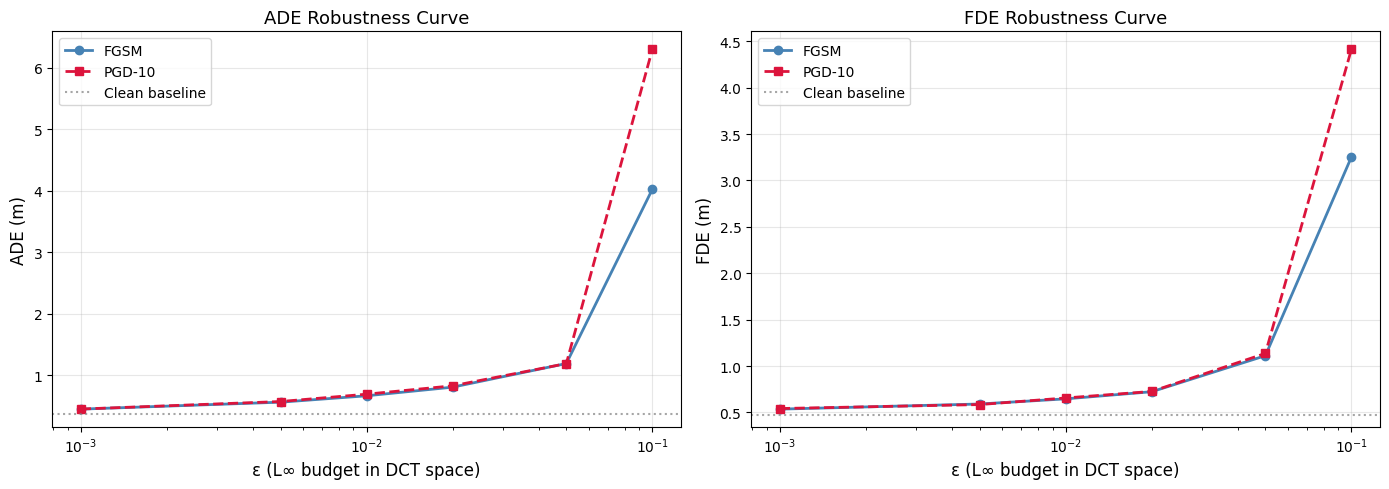

In [20]:
SAVE_DIR = './results/robustness/'
os.makedirs(SAVE_DIR, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ADE robustness curve
ax = axes[0]
fgsm_ade = [fgsm_results[e]['ADE'] for e in eps_values]
pgd_ade  = [pgd_results[e]['ADE'] for e in eps_values]
ax.plot(eps_values, fgsm_ade, 'o-', color='steelblue', linewidth=2, label='FGSM')
ax.plot(eps_values, pgd_ade, 's--', color='crimson', linewidth=2, label='PGD-10')
ax.axhline(baseline_results['ADE'], color='gray', linestyle=':', alpha=0.7, label='Clean baseline')
ax.set_xlabel('ε (L∞ budget in DCT space)', fontsize=12)
ax.set_ylabel('ADE (m)', fontsize=12)
ax.set_title('ADE Robustness Curve', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# FDE robustness curve
ax = axes[1]
fgsm_fde = [fgsm_results[e]['FDE'] for e in eps_values]
pgd_fde  = [pgd_results[e]['FDE'] for e in eps_values]
ax.plot(eps_values, fgsm_fde, 'o-', color='steelblue', linewidth=2, label='FGSM')
ax.plot(eps_values, pgd_fde, 's--', color='crimson', linewidth=2, label='PGD-10')
ax.axhline(baseline_results['FDE'], color='gray', linestyle=':', alpha=0.7, label='Clean baseline')
ax.set_xlabel('ε (L∞ budget in DCT space)', fontsize=12)
ax.set_ylabel('FDE (m)', fontsize=12)
ax.set_title('FDE Robustness Curve', fontsize=13)
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/robustness_curves.png', dpi=150)
plt.show()

## Section 11: Calibration Reliability Diagram

A reliability diagram plots expected coverage vs. observed coverage across multiple confidence levels. For a well-calibrated model, the curve should follow the diagonal. We generate K=50 samples per sequence, compute prediction intervals at multiple confidence levels (50%, 70%, 80%, 90%, 95%), and check what fraction of GT points fall within the interval.

We compare the default model (T=1.0) with the temperature-scaled model (T=best_T).

In [21]:
def compute_calibration(preds, gt, confidence_levels):
    """Compute empirical coverage at each confidence level.
    
    Args:
        preds: (K, N, t_pred, 48) predictions
        gt: (N, t_pred, 48) ground truth
        confidence_levels: list of nominal coverages (e.g. [0.5, 0.7, 0.9])
    Returns:
        coverages: dict {level: empirical_coverage}
    """
    mean_pred = preds.mean(axis=0)  # (N, t_pred, 48)
    # Per-sample spread from mean
    spread = np.linalg.norm(preds - mean_pred[None, ...], axis=-1)  # (K, N, t_pred)
    gt_dist = np.linalg.norm(gt - mean_pred, axis=-1)               # (N, t_pred)

    coverages = {}
    for level in confidence_levels:
        # Radius at this confidence level
        radius = np.percentile(spread, level * 100, axis=0)  # (N, t_pred)
        covered = (gt_dist <= radius).mean()
        coverages[level] = covered
    return coverages

In [22]:
# Guard: load preds_calibrated from cache if not already in scope
if 'preds_calibrated' not in dir() or preds_calibrated is None:
    _cal_preds_cache = os.path.join(CACHE_DIR, 'preds_calibrated.npz')
    if os.path.exists(_cal_preds_cache):
        preds_calibrated = np.load(_cal_preds_cache)['arr']
        print('Loaded preds_calibrated from cache.')
    else:
        raise RuntimeError('preds_calibrated not in scope and no cache found. Run Cell 19 first.')

conf_levels = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

_cal_cov_cache   = os.path.join(CACHE_DIR, 'cal_coverage.json')
_preds_def_cache = os.path.join(CACHE_DIR, 'preds_default.npz')

if os.path.exists(_cal_cov_cache) and os.path.exists(_preds_def_cache):
    with open(_cal_cov_cache) as f:
        _cc = json.load(f)
    cal_default    = {float(k): v for k, v in _cc['cal_default'].items()}
    cal_calibrated = {float(k): v for k, v in _cc['cal_calibrated'].items()}
    preds_default  = np.load(_preds_def_cache)['arr']
    print('Loaded calibration coverage results from cache.')
else:
    # Use adversarial subset — coverage curves don't need all 5168 sequences
    print(f'Generating default (T=1.0) predictions for calibration (N={N_ADV})...')
    preds_default = predict_with_temperature(
        data_group[:N_ADV], model, cfg, diffusion, T=1.0, K=50
    )

    cal_default    = compute_calibration(preds_default, gt_group[:N_ADV], conf_levels)
    cal_calibrated = compute_calibration(preds_calibrated[:, :N_ADV], gt_group[:N_ADV], conf_levels)

    np.savez_compressed(_preds_def_cache, arr=preds_default)
    with open(_cal_cov_cache, 'w') as f:
        json.dump({'cal_default':    {str(k): v for k, v in cal_default.items()},
                   'cal_calibrated': {str(k): v for k, v in cal_calibrated.items()}},
                  f, indent=2)

print('\nCalibration Results:')
print(f'{"Level":>8s}  {"Default":>10s}  {"T-scaled":>10s}')
for level in conf_levels:
    print(f'{level:8.0%}  {cal_default[level]:10.3f}  {cal_calibrated[level]:10.3f}')


Loaded preds_calibrated from cache.
Generating default (T=1.0) predictions for calibration (N=500)...

Calibration Results:
   Level     Default    T-scaled
     50%       0.390       0.641
     60%       0.468       0.713
     70%       0.553       0.782
     80%       0.655       0.844
     90%       0.769       0.907
     95%       0.842       0.943


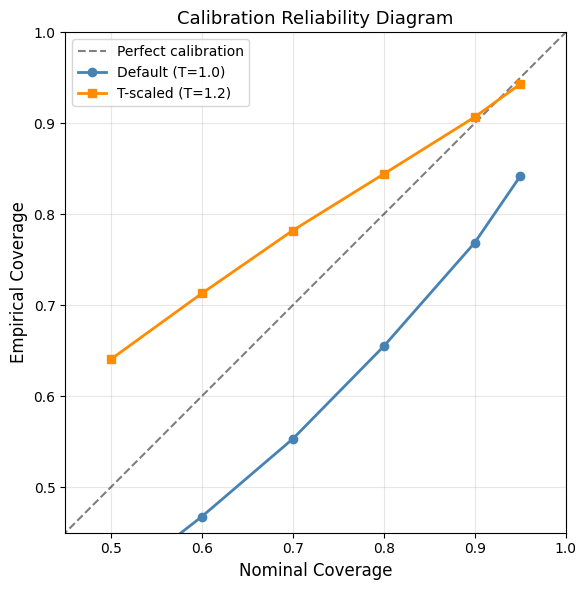

In [23]:
# Reliability diagram
fig, ax = plt.subplots(figsize=(6, 6))

levels_arr = np.array(conf_levels)
default_cov = np.array([cal_default[l] for l in conf_levels])
scaled_cov  = np.array([cal_calibrated[l] for l in conf_levels])

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.plot(levels_arr, default_cov, 'o-', color='steelblue', linewidth=2, label='Default (T=1.0)')
ax.plot(levels_arr, scaled_cov, 's-', color='darkorange', linewidth=2, label=f'T-scaled (T={best_T:.1f})')
ax.set_xlabel('Nominal Coverage', fontsize=12)
ax.set_ylabel('Empirical Coverage', fontsize=12)
ax.set_title('Calibration Reliability Diagram', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(0.45, 1.0)
ax.set_ylim(0.45, 1.0)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/calibration_reliability.png', dpi=150)
plt.show()

## Section 12: Prediction Variance (Confidence) Histograms

Since a diffusion model produces stochastic predictions, the spread among K=50 samples serves as a proxy for model confidence. Low variance = high confidence, high variance = low confidence. We plot per-sequence prediction variance histograms and compare clean vs. adversarial conditions to show how attacks inflate uncertainty.

In [24]:
_variance_cache = os.path.join(CACHE_DIR, 'variance.npz')

if os.path.exists(_variance_cache):
    _vd = np.load(_variance_cache)
    var_clean  = _vd['var_clean']
    var_pgd    = _vd['var_pgd']
    var_jitter = _vd['var_jitter']
    print('Loaded variance arrays from cache.')
else:
    # Per-sequence prediction variance: std across K samples, averaged over time and joints
    # Clean predictions (preds_default already loaded/computed in Section 11)
    var_clean = preds_default.std(axis=0).mean(axis=(1, 2))  # (N,)

    # Adversarial (PGD at highest eps) on the adversarial subset
    eps_high = eps_values[-1]
    print(f'Generating PGD predictions at eps={eps_high} for variance analysis...')
    pgd_preds_high = []
    for k in tqdm(range(50), desc='PGD variance'):
        pred_adv, _ = pgd_attack_dct(
            adv_data_group, model, cfg, diffusion, eps_high, pgd_steps=10, chunk_size=ADV_CHUNK
        )
        pgd_preds_high.append(pred_adv[None, :, cfg.t_his:, :])
    pgd_preds_high = np.concatenate(pgd_preds_high, axis=0)  # (50, N_ADV, t_pred, 48)

    var_pgd = pgd_preds_high.std(axis=0).mean(axis=(1, 2))   # (N_ADV,)

    # Jittered predictions variance (use adversarial subset slice for consistent N)
    var_jitter = pred_jitter_future[:, :N_ADV, :, :].std(axis=0).mean(axis=(1, 2))  # (N_ADV,)

    np.savez_compressed(_variance_cache,
                        var_clean=var_clean, var_pgd=var_pgd, var_jitter=var_jitter)

print(f'var_clean  : mean={var_clean.mean():.4f}')
print(f'var_pgd    : mean={var_pgd.mean():.4f}')
print(f'var_jitter : mean={var_jitter.mean():.4f}')


PGD variance:   0%|          | 0/50 [00:00<?, ?it/s]

Generating PGD predictions at eps=0.1 for variance analysis...


PGD variance: 100%|██████████| 50/50 [54:59<00:00, 66.00s/it]


var_clean  : mean=0.0617
var_pgd    : mean=0.8763
var_jitter : mean=0.0955


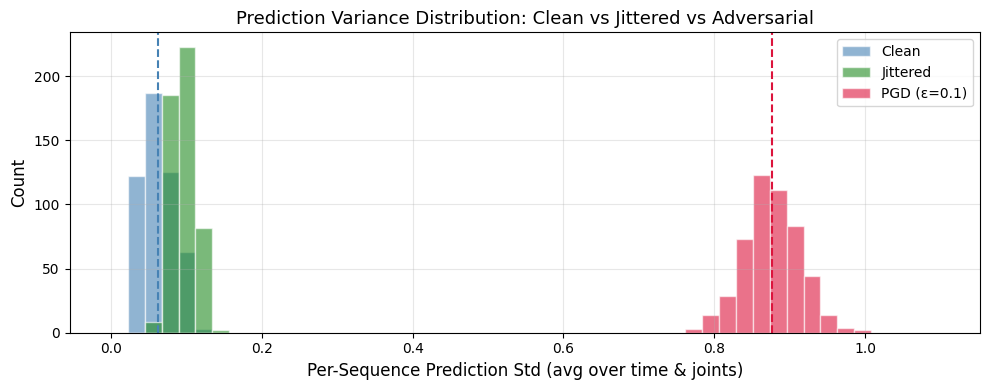

Mean prediction std -- Clean: 0.0617, Jittered: 0.0955, PGD: 0.8763


In [25]:
fig, ax = plt.subplots(figsize=(10, 4))

bins = np.linspace(0, max(var_clean.max(), var_pgd.max(), var_jitter.max()) * 1.1, 50)
ax.hist(var_clean, bins=bins, alpha=0.6, color='steelblue', label='Clean', edgecolor='white')
ax.hist(var_jitter, bins=bins, alpha=0.6, color='forestgreen', label='Jittered', edgecolor='white')
ax.hist(var_pgd, bins=bins, alpha=0.6, color='crimson', label=f'PGD (ε={eps_high})', edgecolor='white')

ax.axvline(var_clean.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(var_pgd.mean(), color='crimson', linestyle='--', linewidth=1.5)

ax.set_xlabel('Per-Sequence Prediction Std (avg over time & joints)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Prediction Variance Distribution: Clean vs Jittered vs Adversarial', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confidence_histograms.png', dpi=150)
plt.show()

print(f'Mean prediction std -- Clean: {var_clean.mean():.4f}, '
      f'Jittered: {var_jitter.mean():.4f}, PGD: {var_pgd.mean():.4f}')

## Section 13: Latency and Memory Benchmarking

Comprehensive efficiency benchmarking covering inference latency (clean vs. adversarial), GPU memory usage, and model size. This closes the MS2 gap for efficiency metrics and provides the data for the deployment readiness assessment in the report.

In [26]:
torch.cuda.reset_peak_memory_stats()
N_BENCH = 100

# Prepare single-sequence benchmark input
bench_data = data_group[:1]
bench_traj_np = bench_data[..., 1:, :].transpose([0, 2, 3, 1])
bench_traj = torch.tensor(bench_traj_np, device=cfg.device, dtype=torch.float32)
bench_traj = bench_traj.reshape([bench_traj.shape[0], -1, bench_traj.shape[-1]]).transpose(1, 2)
bench_mode, bench_dct, bench_cond = sample_preprocessing(bench_traj, cfg, mode='metrics')

# Warm-up
for _ in range(5):
    _ = diffusion.sample_ddim(model, bench_dct, bench_cond, bench_mode)
torch.cuda.synchronize()

# --- Clean inference latency ---
clean_latencies = []
for _ in range(N_BENCH):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = diffusion.sample_ddim(model, bench_dct, bench_cond, bench_mode)
    torch.cuda.synchronize()
    clean_latencies.append((time.perf_counter() - t0) * 1000)
clean_latencies = np.array(clean_latencies)

# --- FGSM attack latency (includes gradient computation) ---
fgsm_latencies = []
for _ in range(N_BENCH):
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = fgsm_attack_dct(bench_data, model, cfg, diffusion, eps=0.01)
    torch.cuda.synchronize()
    fgsm_latencies.append((time.perf_counter() - t0) * 1000)
fgsm_latencies = np.array(fgsm_latencies)

# --- PGD attack latency ---
pgd_latencies = []
for _ in range(min(20, N_BENCH)):  # fewer iterations since PGD is slower
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = pgd_attack_dct(bench_data, model, cfg, diffusion, eps=0.01, pgd_steps=10)
    torch.cuda.synchronize()
    pgd_latencies.append((time.perf_counter() - t0) * 1000)
pgd_latencies = np.array(pgd_latencies)

print('Latency Summary (single sequence):')
print(f'  Clean   -- p50: {np.percentile(clean_latencies, 50):.1f}ms  '
      f'p90: {np.percentile(clean_latencies, 90):.1f}ms  '
      f'mean: {clean_latencies.mean():.1f}ms')
print(f'  FGSM    -- p50: {np.percentile(fgsm_latencies, 50):.1f}ms  '
      f'p90: {np.percentile(fgsm_latencies, 90):.1f}ms  '
      f'mean: {fgsm_latencies.mean():.1f}ms')
print(f'  PGD-10  -- p50: {np.percentile(pgd_latencies, 50):.1f}ms  '
      f'p90: {np.percentile(pgd_latencies, 90):.1f}ms  '
      f'mean: {pgd_latencies.mean():.1f}ms')

Latency Summary (single sequence):
  Clean   -- p50: 2345.4ms  p90: 2444.3ms  mean: 2361.0ms
  FGSM    -- p50: 2419.7ms  p90: 2515.7ms  mean: 2430.9ms
  PGD-10  -- p50: 3030.3ms  p90: 3075.5ms  mean: 3026.2ms


In [27]:
# GPU memory and model size
mem_allocated = torch.cuda.max_memory_allocated() / (1024**2)
mem_reserved  = torch.cuda.max_memory_reserved() / (1024**2)

# Model size on disk
ckpt_size_mb = os.path.getsize(CKPT_PATH) / (1024**2)

print(f'Peak GPU memory allocated : {mem_allocated:.1f} MB')
print(f'Peak GPU memory reserved  : {mem_reserved:.1f} MB')
print(f'Checkpoint file size      : {ckpt_size_mb:.1f} MB')
print(f'Model parameters          : {total_params/1e6:.2f}M')

Peak GPU memory allocated : 348.8 MB
Peak GPU memory reserved  : 550.0 MB
Checkpoint file size      : 108.4 MB
Model parameters          : 28.40M


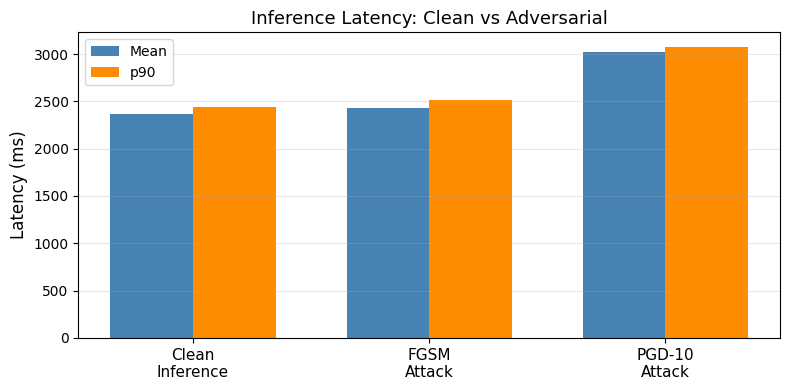

In [28]:
# Latency comparison bar chart
fig, ax = plt.subplots(figsize=(8, 4))

labels = ['Clean\nInference', 'FGSM\nAttack', 'PGD-10\nAttack']
means  = [clean_latencies.mean(), fgsm_latencies.mean(), pgd_latencies.mean()]
p90s   = [np.percentile(clean_latencies, 90),
          np.percentile(fgsm_latencies, 90),
          np.percentile(pgd_latencies, 90)]

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, means, width, label='Mean', color='steelblue')
ax.bar(x + width/2, p90s, width, label='p90', color='darkorange')

ax.set_ylabel('Latency (ms)', fontsize=12)
ax.set_title('Inference Latency: Clean vs Adversarial', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/latency_comparison.png', dpi=150)
plt.show()

## Section 14: Summary Tables

Consolidated results across all conditions: clean baseline, jittering augmentation, temperature scaling, FGSM at each ε, and PGD at each ε. Percentage degradation from baseline is reported for each.

In [29]:
b_ade, b_fde = baseline_results['ADE'], baseline_results['FDE']

rows = []
rows.append({'Condition': 'Clean Baseline', 'ADE': b_ade, 'FDE': b_fde,
             'ADE_delta_%': 0.0, 'FDE_delta_%': 0.0})

rows.append({'Condition': 'Jittering Augmentation',
             'ADE': jitter_results['ADE'], 'FDE': jitter_results['FDE'],
             'ADE_delta_%': (jitter_results['ADE'] - b_ade) / b_ade * 100,
             'FDE_delta_%': (jitter_results['FDE'] - b_fde) / b_fde * 100})

rows.append({'Condition': f'Temp Scaling (T={best_T:.1f})',
             'ADE': calibrated_results['ADE'], 'FDE': calibrated_results['FDE'],
             'ADE_delta_%': (calibrated_results['ADE'] - b_ade) / b_ade * 100,
             'FDE_delta_%': (calibrated_results['FDE'] - b_fde) / b_fde * 100})

for eps in eps_values:
    rows.append({
        'Condition': f'FGSM ε={eps}',
        'ADE': fgsm_results[eps]['ADE'], 'FDE': fgsm_results[eps]['FDE'],
        'ADE_delta_%': (fgsm_results[eps]['ADE'] - b_ade) / b_ade * 100,
        'FDE_delta_%': (fgsm_results[eps]['FDE'] - b_fde) / b_fde * 100
    })

for eps in eps_values:
    rows.append({
        'Condition': f'PGD-10 ε={eps}',
        'ADE': pgd_results[eps]['ADE'], 'FDE': pgd_results[eps]['FDE'],
        'ADE_delta_%': (pgd_results[eps]['ADE'] - b_ade) / b_ade * 100,
        'FDE_delta_%': (pgd_results[eps]['FDE'] - b_fde) / b_fde * 100
    })

df_summary = pd.DataFrame(rows).round(4)
print(df_summary.to_string(index=False))

             Condition    ADE    FDE  ADE_delta_%  FDE_delta_%
        Clean Baseline 0.3691 0.4776       0.0000       0.0000
Jittering Augmentation 0.4825 0.5312      30.7128      11.2364
  Temp Scaling (T=1.2) 0.4059 0.5135       9.9751       7.5363
          FGSM ε=0.001 0.4528 0.5359      22.6730      12.2074
          FGSM ε=0.005 0.5659 0.5911      53.3051      23.7651
           FGSM ε=0.01 0.6695 0.6465      81.3742      35.3821
           FGSM ε=0.02 0.8098 0.7232     119.4028      51.4427
           FGSM ε=0.05 1.1935 1.1115     223.3504     132.7451
            FGSM ε=0.1 4.0247 3.2521     990.3937     580.9770
        PGD-10 ε=0.001 0.4541 0.5423      23.0398      13.5604
        PGD-10 ε=0.005 0.5762 0.5850      56.1147      22.4890
         PGD-10 ε=0.01 0.6955 0.6561      88.4405      37.3880
         PGD-10 ε=0.02 0.8315 0.7264     125.2812      52.1145
         PGD-10 ε=0.05 1.1927 1.1364     223.1312     137.9515
          PGD-10 ε=0.1 6.2976 4.4124    1606.1900     8

## Section 15: Save Results

Export all results to CSV for reproducibility and report generation.

In [30]:
# Save summary table
df_summary.to_csv(f'{SAVE_DIR}/robustness_summary.csv', index=False)

# Save calibration results
cal_rows = []
for level in conf_levels:
    cal_rows.append({
        'nominal_coverage': level,
        'default_coverage': cal_default[level],
        'tscaled_coverage': cal_calibrated[level],
        'best_temperature': best_T
    })
df_cal = pd.DataFrame(cal_rows).round(4)
df_cal.to_csv(f'{SAVE_DIR}/calibration_results.csv', index=False)

# Save latency results
latency_rows = [
    {'method': 'clean', 'p50_ms': np.percentile(clean_latencies, 50),
     'p90_ms': np.percentile(clean_latencies, 90),
     'mean_ms': clean_latencies.mean()},
    {'method': 'fgsm', 'p50_ms': np.percentile(fgsm_latencies, 50),
     'p90_ms': np.percentile(fgsm_latencies, 90),
     'mean_ms': fgsm_latencies.mean()},
    {'method': 'pgd_10', 'p50_ms': np.percentile(pgd_latencies, 50),
     'p90_ms': np.percentile(pgd_latencies, 90),
     'mean_ms': pgd_latencies.mean()},
]
df_latency = pd.DataFrame(latency_rows).round(2)
df_latency.to_csv(f'{SAVE_DIR}/latency_results.csv', index=False)

# Save temperature sweep
temp_rows = [{'temperature': t, 'coverage': c} for t, c in temp_coverages.items()]
pd.DataFrame(temp_rows).round(4).to_csv(f'{SAVE_DIR}/temperature_sweep.csv', index=False)

print(f'All results saved to {SAVE_DIR}')
print('Files: robustness_summary.csv, calibration_results.csv, '
      'latency_results.csv, temperature_sweep.csv')

All results saved to ./results/robustness/
Files: robustness_summary.csv, calibration_results.csv, latency_results.csv, temperature_sweep.csv
